In [1]:
import numpy as np
import math
from joblib import Parallel, delayed
import random
import itertools
from itertools import permutations

In [2]:
def print_state(state,n):
    for i in range(n):
        for j in range(n):
            links=state[i,j]
            print(i,j,':',links)

In [3]:
def sort_state(state,n,n_ch):
    new_state = np.zeros([n,n,n_ch])
    for i in range(n):
        for j in range(n):
            for k in range(n_ch):
                new_state[i,j,k]=state[i,j,k]
        
            new_state[i,j,:] = np.sort(new_state[i,j,:])
    return new_state

def requests(state,n,n_ch,p_l,m):
    new_state = np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    for i in range(n-1):
        active_links = 0
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0:
                    active_links+=1
        
        for k in range(n_ch-active_links):    
            if np.random.random()<p_l:
                new_state[i,i+1,k]=m
                new_state[i+1,i,k]=m
    
    return sort_state(new_state,n,n_ch)  


def waits(state,n,n_ch,m_star,cc=1):
    
    new_state = np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]

    for i in range(n-1):
        for j in range(i+1,n):
            for k in range(n_ch):
                if new_state[i,j,k]>0: # adding CC time to ages of active links
                    new_state[i,j,k]+=cc
                    new_state[j,i,k]+=cc

                if new_state[i,j,k]>m_star: # discarding old links
                    new_state[i,j,k] = 0
                    new_state[j,i,k] = 0

                        
    return(sort_state(new_state,n,n_ch))

In [4]:
def swaps_doubling_maxCC(state, n, n_ch, m_star, priority, a=0):
    if n==2:
        i_list=[]
    if n==3:
        i_list=[1]
    if n==5:
        i_list=[1,3,2]
    if n==9:
        i_list=[1,3,5,7,2,6,4]

    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] =  state[:,:,:]
    cc = []
        
    for i in i_list:
        
        active_sites_r=[] 
        active_sites_local_r=[]  #nodes the i-th node (thinks it) is connected to on the right
        active_ages_r=[]
        active_ages_local_r=[] #perceived age of the link to the right
        active_sites_l=[] 
        active_sites_local_l=[] #nodes the i-th node (thinks it) is connected to on the left
        active_ages_l=[]
        active_ages_local_l=[] #perceived age of the link to the right
        
        #find active or unavailable links to the left and right of the node
        for j in range(i+1,n):
            for k in range(n_ch):
                if i in [1,3,5,7] and np.absolute(i-j)==1:
                    if new_state[i,j,k]!=0:
                        active_sites_r.append(j)
                        active_ages_r.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_r.append(j)
                        active_ages_local_r.append(state[i,j,k])
                    
                            
                if i in [2,6] and np.absolute(i-j)==2:
                    if new_state[i,j,k]!=0:
                        active_sites_r.append(j)
                        active_ages_r.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_r.append(j)
                        active_ages_local_r.append(state[i,j,k])
                    
                            
                if i in [4] and np.absolute(i-j)==4:
                    if new_state[i,j,k]!=0:
                        active_sites_r.append(j)
                        active_ages_r.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_r.append(j)
                        active_ages_local_r.append(state[i,j,k])
                    
        
        for j in range(0,i):
            for k in range(n_ch):
                if i in [1,3,5,7] and np.absolute(i-j)==1:
                    if new_state[i,j,k]!=0:
                        active_sites_l.append(j)
                        active_ages_l.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_l.append(j)
                        active_ages_local_l.append(state[i,j,k])
                   
                            
                if i in [2,6] and np.absolute(i-j)==2:
                    if new_state[i,j,k]!=0:
                        active_sites_l.append(j)
                        active_ages_l.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_l.append(j)
                        active_ages_local_l.append(state[i,j,k])
                            
                if i in [4] and np.absolute(i-j)==4:
                    if new_state[i,j,k]!=0:
                        active_sites_l.append(j)
                        active_ages_l.append(new_state[i,j,k])
                    if state[i,j,k]>0:
                        active_sites_local_l.append(j)
                        active_ages_local_l.append(state[i,j,k])
        
        active_sites_l = np.array(active_sites_l)
        active_sites_r = np.array(active_sites_r)
        active_sites_local_l = np.array(active_sites_local_l)
        active_sites_local_r = np.array(active_sites_local_r)
        active_ages_l = np.array(active_ages_l)
        active_ages_r = np.array(active_ages_r)
        active_ages_local_l = np.array(active_ages_local_l)
        active_ages_local_r = np.array(active_ages_local_r)
        
        dists_i_l = []
        for k in range(len(active_sites_l)):
            dists_i_l.append(-np.absolute(active_sites_l[k] - i))
            
        dists_i_r = []
        for k in range(len(active_sites_r)):
            dists_i_r.append(-np.absolute(active_sites_r[k] - i))
            
        dists_i_local_l = []
        for k in range(len(active_sites_local_l)):
            dists_i_local_l.append(-np.absolute(active_sites_local_l[k] - i))
            
        dists_i_local_r = []
        for k in range(len(active_sites_local_r)):
            dists_i_local_r.append(-np.absolute(active_sites_local_r[k] - i))
        
        dists_i_local_l = np.array(dists_i_local_l)
        dists_i_local_r = np.array(dists_i_local_r)
        dists_i_l = np.array(dists_i_l)
        dists_i_r = np.array(dists_i_r)
        
        if min(len(active_sites_local_l),len(active_sites_local_r))>0: #if at least 1 swap is possible
            if priority=='dist':
                #sort active links based on age
                index_l = np.lexsort((active_ages_local_l,dists_i_local_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_local_r,dists_i_local_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
            
            if priority=='age':
            #sort active links based on distance

                index_l = np.lexsort((dists_i_local_l, active_ages_local_l)) #sort by ages, secondary sort by distance
                index_r = np.lexsort((dists_i_local_r, active_ages_local_r)) #sort by ages, secondary sort by distance
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
            if priority=='mixed':
                weights_l = a*dists_i_local_l/n + (1-a)*active_ages_local_l/m_star
                weights_r = a*dists_i_local_r/n + (1-a)*active_ages_local_r/m_star 
                
                index_l = np.lexsort((active_ages_local_l,weights_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_local_r,weights_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                     
            for j in range(min(len(active_sites_l),len(active_sites_r))):
                
                ch_num_r = np.where(new_state[i,active_sites_r[j]]==active_ages_r[j])[0][0] #right channel num to be broken
                ch_num_l = np.where(new_state[active_sites_l[j],i]==active_ages_l[j])[0][0] #left channel num to be broken
                
                if active_ages_l[j]>0 and active_ages_r[j]>0 and np.random.random()<p_sw and (active_ages_r[j] + active_ages_l[j])<=m_star:
                    inact = np.where(new_state[active_sites_l[j], active_sites_r[j], :]==0)[0][0]
                    new_state[active_sites_l[j], active_sites_r[j], inact] = (active_ages_r[j] + active_ages_l[j] - 1)
                    inact = np.where(new_state[active_sites_r[j], active_sites_l[j], :]==0)[0][0]
                    new_state[active_sites_r[j], active_sites_l[j], inact]  = (active_ages_r[j] + active_ages_l[j] - 1)
                
                else:
                    inact = np.where(new_state[active_sites_l[j], active_sites_r[j], :]==0)[0][0]
                    new_state[active_sites_l[j], active_sites_r[j], inact] = -(np.absolute(active_ages_r[j]) + np.absolute(active_ages_l[j]) - 1)
                    inact = np.where(new_state[active_sites_r[j], active_sites_l[j], :]==0)[0][0]
                    new_state[active_sites_r[j], active_sites_l[j], inact] = -(np.absolute(active_ages_r[j]) + np.absolute(active_ages_l[j]) - 1)
                        
                new_state[i,active_sites_r[j],ch_num_r]=0
                new_state[active_sites_r[j],i,ch_num_r]=0
                new_state[active_sites_l[j],i,ch_num_l]=0
                new_state[i,active_sites_l[j],ch_num_l]=0
                        
#                 new_state=sort_state(new_state,n,n_ch)
            
            cc.append(max(np.max(-dists_i_l), np.max(-dists_i_r)))
            
    for i in range(n):
        for j in range(n):
            for k in range(n_ch):
                if new_state[i,j,k]<0:
                    new_state[i,j,k]=0
    if len(cc)==0:
        return sort_state(new_state,n,n_ch), 1
    else:
        return sort_state(new_state,n,n_ch), np.max(cc)

In [5]:
def swaps_maxCC(state, n, n_ch, m_star, priority, a=0):
    i_list=[]
    if n%2==1:
        for ll in range(1,int(n/2)):
                i_list.append(ll)
                i_list.append(n-ll-1)
        i_list.append(int(n/2))
    else:
        for ll in range(1,int(n/2)):
                i_list.append(ll)
                i_list.append(n-ll-1)
    
    i_list = np.array(i_list)
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] =  state[:,:,:]
    cc = []
        
    for i in i_list:
        
        active_sites_r=[] 
        active_sites_local_r=[]  #nodes the i-th node (thinks it) is connected to on the right
        active_ages_r=[]
        active_ages_local_r=[] #perceived age of the link to the right
        active_sites_l=[] 
        active_sites_local_l=[] #nodes the i-th node (thinks it) is connected to on the left
        active_ages_l=[]
        active_ages_local_l=[] #perceived age of the link to the right
        
        #find active or unavailable links to the left and right of the node
        for j in range(i+1,n):
            for k in range(n_ch):
                
                if new_state[i,j,k]!=0:
                    active_sites_r.append(j)
                    active_ages_r.append(new_state[i,j,k])
                if state[i,j,k]>0:
                    active_sites_local_r.append(j)
                    active_ages_local_r.append(state[i,j,k])
                            
        
        for j in range(0,i):
            for k in range(n_ch):
                
                if new_state[i,j,k]!=0:
                    active_sites_l.append(j)
                    active_ages_l.append(new_state[i,j,k])
                if state[i,j,k]>0:
                    active_sites_local_l.append(j)
                    active_ages_local_l.append(state[i,j,k])
                            
        
        active_sites_l = np.array(active_sites_l)
        active_sites_r = np.array(active_sites_r)
        active_sites_local_l = np.array(active_sites_local_l)
        active_sites_local_r = np.array(active_sites_local_r)
        active_ages_l = np.array(active_ages_l)
        active_ages_r = np.array(active_ages_r)
        active_ages_local_l = np.array(active_ages_local_l)
        active_ages_local_r = np.array(active_ages_local_r)
        
        dists_i_l = []
        for k in range(len(active_sites_l)):
            dists_i_l.append(-np.absolute(active_sites_l[k] - i))
            
        dists_i_r = []
        for k in range(len(active_sites_r)):
            dists_i_r.append(-np.absolute(active_sites_r[k] - i))
            
        dists_i_local_l = []
        for k in range(len(active_sites_local_l)):
            dists_i_local_l.append(-np.absolute(active_sites_local_l[k] - i))
            
        dists_i_local_r = []
        for k in range(len(active_sites_local_r)):
            dists_i_local_r.append(-np.absolute(active_sites_local_r[k] - i))
        
        dists_i_local_l = np.array(dists_i_local_l)
        dists_i_local_r = np.array(dists_i_local_r)
        dists_i_l = np.array(dists_i_l)
        dists_i_r = np.array(dists_i_r)
        
#         print(i)
#         print(len(active_sites_l), len(active_sites_local_l), len(active_sites_r), len(active_sites_local_r))
#         print_state(state,n)
#         print("")
#         print_state(new_state,n)
#         print("")
#         print(len(active_sites_l), len(active_sites_local_l), len(active_sites_r), len(active_sites_local_r))
        
        if min(len(active_sites_l),len(active_sites_r))>0: #if at least 1 swap is possible
            if priority=='dist':
                #sort active links based on age
                index_l = np.lexsort((active_ages_local_l,dists_i_local_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_local_r,dists_i_local_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
            
            if priority=='age':
            #sort active links based on distance

                index_l = np.lexsort((dists_i_local_l, active_ages_local_l)) #sort by ages, secondary sort by distance
                index_r = np.lexsort((dists_i_local_r, active_ages_local_r)) #sort by ages, secondary sort by distance
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
            
            if priority=='mixed':
                weights_l = a*dists_i_local_l/n + (1-a)*active_ages_local_l/m_star
                weights_r = a*dists_i_local_r/n + (1-a)*active_ages_local_r/m_star 
                
                index_l = np.lexsort((active_ages_local_l,weights_l)) #sort by distance, secondary sort by ages
                index_r = np.lexsort((active_ages_local_r,weights_r)) #sort by distance, secondary sort by ages
                active_sites_l = active_sites_l[index_l]
                active_ages_l = active_ages_l[index_l]
                active_sites_r = active_sites_r[index_r]
                active_ages_r = active_ages_r[index_r]
                
                    
            for j in range(min(len(active_sites_l),len(active_sites_r))):
                
                ch_num_r = np.where(new_state[i,active_sites_r[j]]==active_ages_r[j])[0][0] #right channel num to be broken
                ch_num_l = np.where(new_state[active_sites_l[j],i]==active_ages_l[j])[0][0] #left channel num to be broken
                
                if active_ages_l[j]>0 and active_ages_r[j]>0 and np.random.random()<p_sw and (active_ages_r[j] + active_ages_l[j])<=m_star:
                    inact = np.where(new_state[active_sites_l[j], active_sites_r[j], :]==0)[0][0]
                    new_state[active_sites_l[j], active_sites_r[j], inact] = (active_ages_r[j] + active_ages_l[j] - 1)
                    inact = np.where(new_state[active_sites_r[j], active_sites_l[j], :]==0)[0][0]
                    new_state[active_sites_r[j], active_sites_l[j], inact]  = (active_ages_r[j] + active_ages_l[j] - 1)
                
                else:
                    inact = np.where(new_state[active_sites_l[j], active_sites_r[j], :]==0)[0][0]
                    new_state[active_sites_l[j], active_sites_r[j], inact] = -(np.absolute(active_ages_r[j]) + np.absolute(active_ages_l[j]) - 1)
                    inact = np.where(new_state[active_sites_r[j], active_sites_l[j], :]==0)[0][0]
                    new_state[active_sites_r[j], active_sites_l[j], inact] = -(np.absolute(active_ages_r[j]) + np.absolute(active_ages_l[j]) - 1)
                        
                new_state[i,active_sites_r[j],ch_num_r]=0
                new_state[active_sites_r[j],i,ch_num_r]=0
                new_state[active_sites_l[j],i,ch_num_l]=0
                new_state[i,active_sites_l[j],ch_num_l]=0
                    
                        
#             new_state=sort_state(new_state,n,n_ch)
            
            cc.append(max(np.max(-dists_i_l), np.max(-dists_i_r)))
            
    for i in range(n):
        for j in range(n):
            for k in range(n_ch):
                if new_state[i,j,k]<0:
                    new_state[i,j,k]=0
    if len(cc)==0:
        return sort_state(new_state,n,n_ch), 1
    else:
        return sort_state(new_state,n,n_ch), np.max(cc)

In [6]:
# bunching distillation
def distill_maxCC(state,n,n_ch,m_star,K):
    d_cc=[]
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    d_len=1
    for i in range(n):
        for j in range(i+1,n):
            for ii in range(K):
                active_links = len(np.where(new_state[i,j]>0)[0])
                if active_links<=1:
                    break
                k = 0
                while k < (n_ch-1):
                    non_fresh_channels=[]
                    non_fresh_ages=[]
                    if new_state[i,j,k]>1:
                        non_fresh_channels.append(k)
                        non_fresh_ages.append(new_state[i,j,k])
                        non_fresh_channels.append(k+1)
                        non_fresh_ages.append(new_state[i,j,k+1])

                    if len(non_fresh_ages)==2:
                        d_len = np.absolute(i-j)
                        f1 = 0.25*(1+3*math.exp(-(non_fresh_ages[0]-1)/m_star))
                        f2 = 0.25*(1+3*math.exp(-(non_fresh_ages[1]-1)/m_star))
                        p_ds = (8/9)*f1*f2 - (2/9)*(f1+f2) + (5/9)
                        f_success = (1-(f1+f2)+10*f1*f2)/(5-2*(f1+f2)+8*f1*f2)
                        m_success = int(-1*m_star*np.log((4*f_success - 1)/3))
                        if np.random.random()<p_ds:
    #                         print(f1,f2)
                            new_state[i,j,non_fresh_channels[1]] = 1 + m_success
                            new_state[j,i,non_fresh_channels[1]] = 1 + m_success
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0 
                        else:
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0
                            new_state[i,j,non_fresh_channels[1]] = 0
                            new_state[j,i,non_fresh_channels[1]] = 0
                            
                            for k in range(n_ch-1):
                                new_state[i,j,k] = 0
                                new_state[j,i,k] = 0
                            
                            break       

                    k+=2
#                 new_state = sort_state(new_state,n,n_ch)
            d_cc.append(d_len)
    return sort_state(new_state,n,n_ch), np.max(d_cc)


# bunching distillation
def distill_fullCC(state,n,n_ch,m_star,K):
    d_cc=[]
    new_state=np.zeros([n,n,n_ch])
    new_state[:,:,:] = state[:,:,:]
    
    for i in range(n):
        for j in range(i+1,n):
            d_len = 0
            for ii in range(K):
                active_links = len(np.where(new_state[i,j]>0)[0])
                if active_links<=1:
                    break
                d_len+=np.absolute(i-j)
                k = 0
                while k < (n_ch-1):
                    non_fresh_channels=[]
                    non_fresh_ages=[]
                    if new_state[i,j,k]>1:
                        non_fresh_channels.append(k)
                        non_fresh_ages.append(new_state[i,j,k])
                        non_fresh_channels.append(k+1)
                        non_fresh_ages.append(new_state[i,j,k+1])

                    if len(non_fresh_ages)==2:
                        f1 = 0.25*(1+3*math.exp(-(non_fresh_ages[0]-1)/m_star))
                        f2 = 0.25*(1+3*math.exp(-(non_fresh_ages[1]-1)/m_star))
                        p_ds = (8/9)*f1*f2 - (2/9)*(f1+f2) + (5/9)
                        f_success = (1-(f1+f2)+10*f1*f2)/(5-2*(f1+f2)+8*f1*f2)
                        m_success = int(-1*m_star*np.log((4*f_success - 1)/3))
                        if np.random.random()<p_ds:
    #                         print(f1,f2)
                            new_state[i,j,non_fresh_channels[1]] = 1 + m_success
                            new_state[j,i,non_fresh_channels[1]] = 1 + m_success
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0 
                        else:
                            new_state[i,j,non_fresh_channels[0]] = 0
                            new_state[j,i,non_fresh_channels[0]] = 0
                            new_state[i,j,non_fresh_channels[1]] = 0
                            new_state[j,i,non_fresh_channels[1]] = 0

                    k+=2
                new_state = sort_state(new_state,n,n_ch)
            d_cc.append(d_len)
    return sort_state(new_state,n,n_ch), np.max(d_cc)

In [7]:
def wt_fid_CC(n,n_ch,m_star,p_l,p_sw,priority,m=1,K=10,a=0,dl=False,sw_dl=False):
    state=np.zeros([n,n,n_ch])
    wt=0
    cc_total = np.zeros(int(n))
    while len(np.where(state[0][n-1]>0)[0])==0:
        
        state=requests(state,n,n_ch,p_l,m) 
#         print_state(state,n)
#         print('')
        if dl:
            if sw_dl:
                state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
                state,cc_d=distill_maxCC(state,n,n_ch,m_star,K)
            else:
                state,cc_d=distill_maxCC(state,n,n_ch,m_star,K)  
                state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
        else:
            state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
#             print_state(state,n)
#             print('')
        
        if dl:
            state=waits(state,n,n_ch,m_star,cc+cc_d)
            wt+=(cc+cc_d)
        else:
            state=waits(state,n,n_ch,m_star,cc)
#             print_state(state,n)
#             print('')
            wt+=(cc)
        cc_total[int(cc)]+=1
    return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)]),cc_total

def wt_fid_fullCC(n,n_ch,m_star,p_l,p_sw,priority,m=1,K=10,a=0,dl=False,sw_dl=False):
    state=np.zeros([n,n,n_ch])
    wt=0
#     cc_total = np.zeros(int(n))
    while len(np.where(state[0][n-1]>0)[0])==0:
        
        state=requests(state,n,n_ch,p_l,m) 
#         print_state(state,n)
#         print('')
        if dl:
            if sw_dl:
                state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
                state,cc_d=distill_fullCC(state,n,n_ch,m_star,K)
            else:
                state,cc_d=distill_fullCC(state,n,n_ch,m_star,K)  
                state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
        else:
            state,cc=swaps_maxCC(state,n,n_ch,m_star,priority,a)
#             print_state(state,n)
#             print('')
        
        if dl:
            state=waits(state,n,n_ch,m_star,cc+cc_d)
            wt+=(cc+cc_d)
        else:
            state=waits(state,n,n_ch,m_star,cc)
#             print_state(state,n)
#             print('')
            wt+=(cc)
#         cc_total[int(cc+cc_d)]+=1
    return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)])


def wt_fid_doubling_CC(n,n_ch,m_star,p_l,p_sw,priority,m=1,K=10,a=0,dl=False,sw_dl=False):
    state=np.zeros([n,n,n_ch])
    wt=0
    cc_total = np.zeros(int(n))
    while len(np.where(state[0][n-1]>0)[0])==0:
        state=requests(state,n,n_ch,p_l,m) 
        if dl:
            if sw_dl:
                state,cc=swaps_doubling_maxCC(state,n,n_ch,m_star,priority,a)
                state,cc_d=distill_maxCC(state,n,n_ch,m_star,K)
            else:
                state,cc_d=distill_maxCC(state,n,n_ch,m_star,K)  
                state,cc=swaps_doubling_maxCC(state,n,n_ch,m_star,priority,a)
        else:
            state,cc=swaps_doubling_maxCC(state,n,n_ch,m_star,priority,a)
        
        if dl:
            state=waits(state,n,n_ch,m_star,cc+cc_d)
            wt+=(cc+cc_d)
        else:
            state=waits(state,n,n_ch,m_star,cc)
            wt+=(cc)
        cc_total[int(cc)]+=1
    return wt,np.min(state[0,n-1][np.where(state[0,n-1]>0)]),cc_total

In [8]:
n=8

i_list=[]
if n%2==1:
    for ll in range(1,int(n/2)):
            i_list.append(ll)
            i_list.append(n-ll-1)
    i_list.append(int(n/2))
else:
    for ll in range(1,int(n/2)):
            i_list.append(ll)
            i_list.append(n-ll-1)

i_list = np.array(i_list)
i_list

array([1, 6, 2, 5, 3, 4])

In [16]:
wt_all = []
fid_all = []
wt_std = []
fid_std = []

n_ch = 5
p_sw = 0.5

for n in range(5,6):
    print(n)
    dt = max(1/6000, 1.5*100e3/3e8/(n-1))
    dwf1 = 0.69
    dwf2 = 0.5
    p_l1 = 0.79*math.exp(-100/12/(n-1))*dwf1**2
    p_l2 = 0.79*math.exp(-100/12/(n-1))*dwf2**2
    m_star1 = int(1.2e-3/dt)
    m_star2 = int(13e-3/dt)
    f01 = 0.99
    f02 = 0.99
    m0_1 = int(-m_star1*math.log(abs(4*0.93*(f01)**2 - 1)/3))
    m0_2 = int(-m_star2*math.log(abs(4*0.93*(f02)**2 - 1)/3))
    print([m0_1, m0_2, m_star1, m_star2, p_l1, p_l2])
    
    wt_wt = []
    fid_fid = []

    for k in range(20):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid_CC)(n,n_ch,m_star2+1,p_l2,p_sw,'dist',m0_2+1,dl=False,sw_dl=False) for i in range(1000))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)
#         cc_cc.append([wt_list[i][2] for i in range(len(wt_list))])
#         cc_all.append(np.mean(cc_cc,axis=1))
    wt_all.append(np.mean(wt_wt)*dt)
    fid_all.append(0.25*(1+3*math.exp(-(np.mean(fid_fid))/m_star2)))
    print(wt_all)
    print(np.std(wt_wt))
    print(fid_all)
    
#     np.save('wt_Diapt5_real.npy', wt_all)
#     np.save('fid_Diapt5_real.npy', fid_all)

# wt_all = []
# fid_all = []
# wt_std = []
# fid_std = []

# n_ch = 5
# p_sw = 1

# for n in range(2,10):
#     print(n)
#     dt = max(1/6000,1.5*100e3/3e8/(n-1))
#     dwf1 = 0.69
#     dwf2 = 0.5
#     p_l1 = 0.79*math.exp(-100/12/(n-1))*dwf1**2
#     p_l2 = 0.79*math.exp(-100/12/(n-1))*dwf2**2
#     m_star1 = 1.2e-3/dt
#     m_star2 = 13e-3/dt
#     m0_1 = int(-m_star1*math.log(abs(4*0.93*0.98**2 - 1)/3))
#     m0_2 = int(-m_star2*math.log(abs(4*0.93*0.94**2 - 1)/3))
#     print([m0_1, m0_2, m_star1, m_star2])
#     wt_wt = []
#     fid_fid = []

#     for k in range(1):
#         wt_list = Parallel(n_jobs=50)(delayed(wt_fid_CC)(n,n_ch,m_star2,p_l2,p_sw,'dist',m0_2+1,dl=False,sw_dl=False) for i in range(50))
#         wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
#         fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)
# #         cc_cc.append([wt_list[i][2] for i in range(len(wt_list))])
# #         cc_all.append(np.mean(cc_cc,axis=1))
#     wt_all.append(np.mean(wt_wt))
#     fid_all.append(np.mean(fid_fid))
#     print(wt_all)    
#     print(fid_all)

# wt_all = []
# fid_all = []
# wt_std = []
# fid_std = []

# n_ch = 5
# p_sw = 0.5

# for n in range(2,10):
#     print(n)
#     dt = max(1/6000,1.5*100e3/3e8/(n-1))
#     dwf1 = 0.69
#     dwf2 = 0.5
#     p_l1 = 0.79*math.exp(-100/12/(n-1))*dwf1**2
#     p_l2 = 0.79*math.exp(-100/12/(n-1))*dwf2**2
#     m_star1 = 1.2e-3/dt
#     m_star2 = 13e-3/dt
#     m0_1 = int(-m_star1*math.log(abs(4*0.93*0.98**2 - 1)/3))
#     m0_2 = int(-m_star2*math.log(abs(4*0.93*0.89**2 - 1)/3))
    
#     wt_wt = []
#     fid_fid = []

#     for k in range(1):
#         wt_list = Parallel(n_jobs=100)(delayed(wt_fid_CC)(n,n_ch,m_star1,p_l1,p_sw,'dist',m0_1+1,dl=False,sw_dl=False) for i in range(200))
#         wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
#         fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)
#         print(wt_wt)
# #         cc_cc.append([wt_list[i][2] for i in range(len(wt_list))])
# #         cc_all.append(np.mean(cc_cc,axis=1))
#     wt_all.append(np.mean(wt_wt))
#     fid_all.append(np.mean(fid_fid))
#     print(wt_all)    
#     print(fid_all)
    
# wt_all = []
# fid_all = []
# wt_std = []
# fid_std = []

# n_ch = 5
# p_sw = 0.5

# for n in range(2,10):
#     print(n)
#     dt = max(1/6000,1.5*100e3/3e8/(n-1))
#     dwf1 = 0.69
#     dwf2 = 0.5
#     p_l1 = 0.79*math.exp(-100/12/(n-1))*dwf1**2
#     p_l2 = 0.79*math.exp(-100/12/(n-1))*dwf2**2
#     m_star1 = 1.2e-3/dt
#     m_star2 = 13e-3/dt
#     m0_1 = int(-m_star1*math.log(abs(4*0.93*0.98**2 - 1)/3))
#     m0_2 = int(-m_star2*math.log(abs(4*0.93*0.89**2 - 1)/3))
    
#     wt_wt = []
#     fid_fid = []

#     for k in range(1):
#         wt_list = Parallel(n_jobs=100)(delayed(wt_fid_CC)(n,n_ch,m_star2,p_l2,p_sw,'dist',m0_2+1,dl=False,sw_dl=False) for i in range(200))
#         wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
#         fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)
#         print(wt_wt)
# #         cc_cc.append([wt_list[i][2] for i in range(len(wt_list))])
# #         cc_all.append(np.mean(cc_cc,axis=1))
#     wt_all.append(np.mean(wt_wt))
#     fid_all.append(np.mean(fid_fid))
#     print(wt_all)    
#     print(fid_all)

5
[0, 9, 7, 78, 0.04683225848509208, 0.024591608110214287]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
[np.float64(0.015649791666666666)]
2.916769803652665
[0.6096450012544334]


In [18]:
2.916*dt/0.0156

0.031153846153846153

[  0.92058737  19.11223661 150.55706113 190.58509625 108.80011605
  56.05643014  19.75796493   7.96701655   2.79797632]
[ 0.91084553 19.75884332 53.22121398 19.22239024]


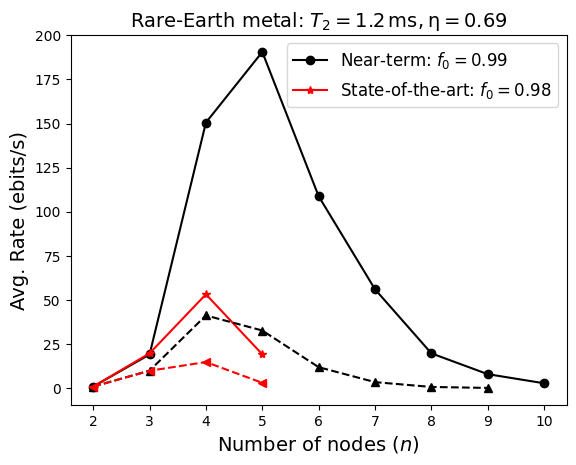

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import math
wt = 1/np.load('wt_RE1.npy')
wt_real = 1/np.load('wt_RE1_real.npy')

wtpt5 = 1/np.load('wt_REpt5.npy')
wtpt5_real = 1/np.load('wt_REpt5_real.npy')

print(wt)
print(wt_real)

plt.plot(range(2,len(wt)+2), wt, marker='o', color='black')
plt.plot(range(2,len(wt_real)+2), wt_real, marker='*', color='red')

plt.plot(range(2,len(wtpt5)+2), wtpt5, marker='^', color='black', linestyle='--')
plt.plot(range(2,len(wtpt5_real)+2), wtpt5_real, marker='<', color='red', linestyle='--')

plt.ylabel('Avg. Rate (ebits/s)', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
# plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.20, f_0 = 0.89$', fontsize=14)
plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69$', fontsize=14)
plt.legend([r"Near-term: $f_0 = 0.99$","State-of-the-art: $f_0 = 0.98$"], fontsize=12)
plt.savefig('RE_wt_comp.pdf')

[0.70489799 0.63483828 0.60655973 0.58743028 0.56823417 0.56389961
 0.55733254 0.55856433 0.54727114]
[0.70489799 0.63851167 0.55176381 0.5351665 ]


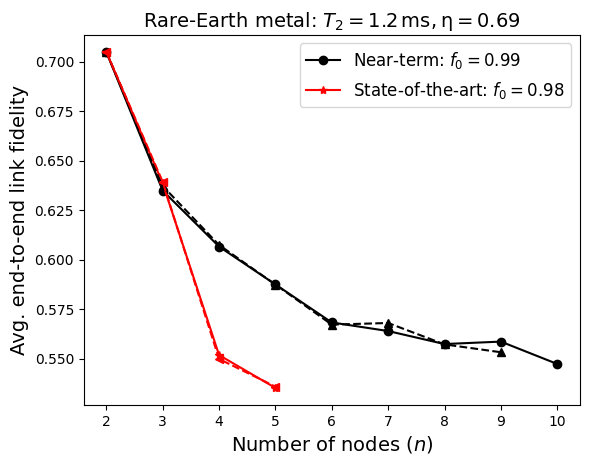

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import math
fid = np.load('fid_RE1.npy')
fid_real = np.load('fid_RE1_real.npy')

fidpt5 = np.load('fid_REpt5.npy')
fidpt5_real = np.load('fid_REpt5_real.npy')

print(fid)
print(fid_real)

plt.plot(range(2,len(fid)+2), fid, marker='o', color='black')
plt.plot(range(2,len(fid_real)+2), fid_real, marker='*', color='red')

plt.plot(range(2,len(fidpt5)+2), fidpt5, marker='^', color='black', linestyle='--')
plt.plot(range(2,len(fidpt5_real)+2), fidpt5_real, marker='<', color='red', linestyle='--')

plt.ylabel('Avg. end-to-end link fidelity', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
# plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.20, f_0 = 0.89$', fontsize=14)
plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69$', fontsize=14)
plt.legend([r"Near-term: $f_0 = 0.99$","State-of-the-art: $f_0 = 0.98$"], fontsize=12)
plt.savefig('RE_fid_comp.pdf')

[  0.46893461  29.63116606 182.23788118 297.79630733 342.44620741
 237.44509082  14.35561245]
[0.46325121 9.60633249]


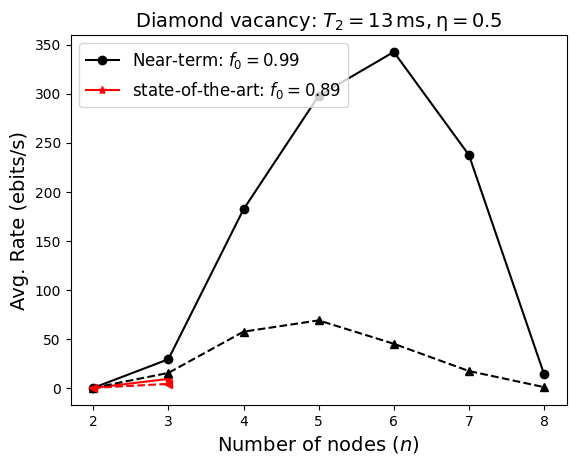

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import math
wt = 1/np.load('wt_Dia1.npy')
wt_real = 1/np.load('wt_Dia1_real.npy')

wtpt5 = 1/np.load('wt_Diapt5.npy')
wtpt5_real = 1/np.load('wt_Diapt5_real.npy')

print(wt)
print(wt_real)

plt.plot(range(2,len(wt)+2), wt, marker='o', color='black')
plt.plot(range(2,len(wt_real)+2), wt_real, marker='*', color='red')

plt.plot(range(2,len(wtpt5)+2), wtpt5, marker='^', color='black', linestyle='--')
plt.plot(range(2,len(wtpt5_real)+2), wtpt5_real, marker='<', color='red', linestyle='--')

plt.ylabel('Avg. Rate (ebits/s)', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.5$', fontsize=14)
# plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69, f_0 = 0.98$', fontsize=14)
plt.legend([r"Near-term: $f_0 = 0.99$","state-of-the-art: $f_0 = 0.89$"], fontsize=12, loc = 'upper left')
plt.savefig('Dia_wt_comp.pdf')

[0.89305294 0.67489515 0.66323197 0.63226898 0.59073726 0.55334807
 0.53350423]
[0.72273489 0.54500617]


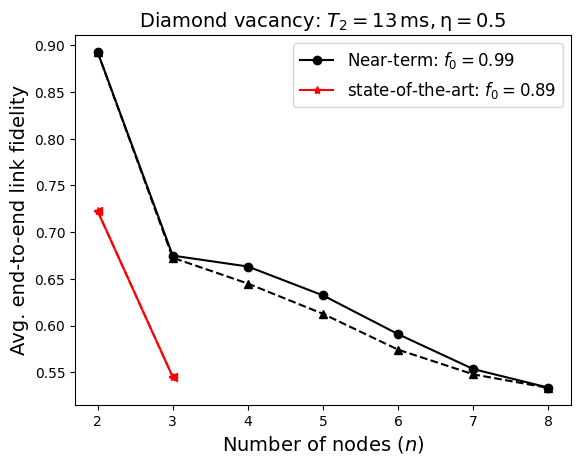

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import math
fid = np.load('fid_Dia1.npy')
fid_real = np.load('fid_Dia1_real.npy')

fidpt5 = np.load('fid_Diapt5.npy')
fidpt5_real = np.load('fid_Diapt5_real.npy')

print(fid)
print(fid_real)


plt.plot(range(2,len(fid)+2), fid, marker='o', color='black')
plt.plot(range(2,len(fid_real)+2), fid_real, marker='*', color='red')

plt.plot(range(2,len(fidpt5)+2), fidpt5, marker='^', color='black', linestyle='--')
plt.plot(range(2,len(fidpt5_real)+2), fidpt5_real, marker='<', color='red', linestyle='--')

plt.ylabel('Avg. end-to-end link fidelity', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.5$', fontsize=14)
# plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69, f_0 = 0.98$', fontsize=14)
plt.legend([r"Near-term: $f_0 = 0.99$","state-of-the-art: $f_0 = 0.89$"], fontsize=12, loc = 'upper right')
plt.savefig('Dia_fid_comp.pdf')

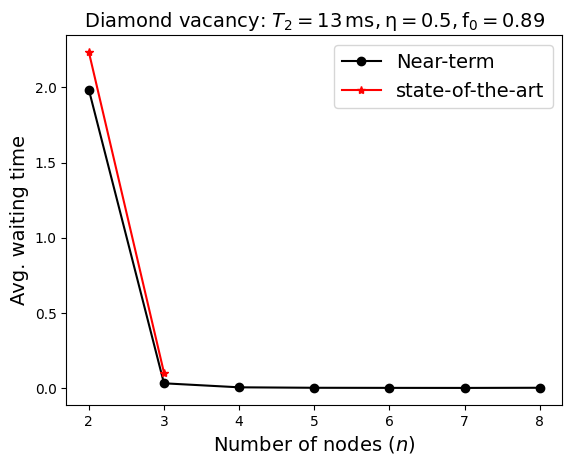

In [36]:
wt = np.load('wt_Dia1.npy')
wt_real = np.load('wt_Dia1_real.npy')

plt.plot(range(2,len(wt)+2), wt, marker='o', color='black')
plt.plot(range(2,len(wt_real)+2), wt_real, marker='*', color='red')
plt.ylabel('Avg. waiting time', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.5, f_0 = 0.89$', fontsize=14)
# plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69, f_0 = 0.98$', fontsize=14)
plt.legend([r"Near-term","state-of-the-art"], fontsize=14)
plt.savefig('RE_wt_comp.pdf')

9.04075271014312e-05
0.005831293911805783
0.023385772038674355
0.04683225848509208
0.07103970286366092
0.09378610341310784
7.595675454856647e-06
2.4 26.0
0.0004899217737286944
4.8 52.0
0.0019647781590988755
7.199999999999999 78.0
0.003934657297634286
9.6 104.0
0.005968469049666956
11.999999999999998 130.0
0.007879529797362561
14.399999999999999 156.0


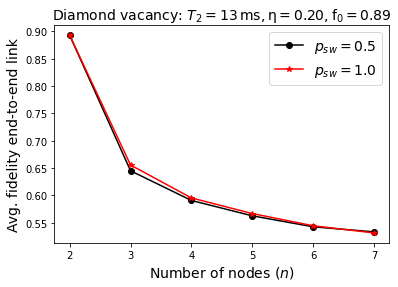

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import math

wt_RE = np.array([1183.096,
 197.48899999999998,
 60.94,
 49.541999999999994,
 83.01899999999999,
 136.45999999999998,
 277.871,
 515.587,
 1044.548,
 2202.1800000000003])
# wt_RE_doubling = np.array([1250.684, 149.93400000000003, 53.891, 793.043])
wt_RE1 = [1196.822,
 93.963,
 15.858,
 8.903,
 9.923999999999998,
 10.234000000000002,
 12.287000000000003,
 14.989999999999998,
 16.844,
 25.851]
fid_RE = np.array([1.0,
 2.114,
 4.449,
 5.734,
 7.441000000000001,
 9.662,
 11.39,
 13.936999999999998,
 15.776999999999997,
 17.752999999999997])
fid_RE1 = np.array([1.0,
 2.101,
 4.357,
 5.585000000000001,
 7.005,
 8.815,
 10.094,
 12.475,
 14.003,
 16.509999999999998])

# fid_RE_doubling = np.array([1.0, 2.584, 6.68, 15.913])

wt_dia = np.array([14372.050999999998, 1966.0169999999998, 863.628, 979.7270000000001, 2863.306, 50642.246])
wt_dia1 = np.array([14510.298999999999,
 990.9129999999999,
 257.255,
 154.502,
 320.826,
 69118.18100000001])
fid_dia = np.array([5.0, 34.31400000000001, 62.497, 91.946, 123.30799999999999, 152.78400000000002])
fid_dia1 = np.array([5.0, 32.945, 61.444, 90.564, 122.47200000000001, 153.839])
i=0
for n in range(2,8):
    dt = 1.5*100e3/3e8/(n-1)
    p_l = 0.79*math.exp(-100/12/(n-1))*0.69**2
    print(p_l)
    wt_RE[i] = wt_RE[i]*dt
    wt_dia[i] = wt_dia[i]*dt
    wt_RE1[i] = wt_RE1[i]*dt
    wt_dia1[i] = wt_dia1[i]*dt
    i+=1
i=0    
for n in range(2,8):
    dt = 1.5*100e3/3e8/(n-1)
    p_l = 0.79*math.exp(-100/12/(n-1))*0.20**2
    print(p_l)
    m_star1 = 1.2e-3/dt
    m_star2 = 13e-3/dt
    print(m_star1, m_star2)
    
    fid_RE[i] = 0.25*(1+3*math.exp(-(fid_RE[i]-1)/m_star1))
    fid_dia[i] = 0.25*(1+3*math.exp(-(fid_dia[i]-1)/m_star2))
    fid_RE1[i] = 0.25*(1+3*math.exp(-(fid_RE1[i]-1)/m_star1))
    fid_dia1[i] = 0.25*(1+3*math.exp(-(fid_dia1[i]-1)/m_star2))
    i+=1

plt.plot(range(2,8), fid_dia, marker='o', color='black')
plt.plot(range(2,8), fid_dia1, marker='*', color='red')
plt.ylabel('Avg. fidelity end-to-end link', fontsize=14)
# plt.yscale('log')
plt.xlabel('Number of nodes ($n$)', fontsize=14)
plt.title(r'Diamond vacancy: $T_2 = 13\, \rm ms, \eta = 0.20, f_0 = 0.89$', fontsize=14)
# plt.title(r'Rare-Earth metal: $T_2 = 1.2\, \rm ms, \eta = 0.69, f_0 = 0.98$', fontsize=14)
plt.legend([r"$p_{sw} = 0.5$","$p_{sw} = 1.0$"], fontsize=14)
plt.savefig('Dia_fid.pdf')

# print(fid_dia[3])

In [35]:
1/0.00625

160.0

In [14]:
import math
import numpy as np
T2 = 1.2e-3
dwf = 0.69
f0 = 0.98
wt_all=[]
fid_all=[]
K=4
for n in [2,3,5,9]:
    dt = 1.5*100e3/3e8/(n-1)
    m_star = int(T2/dt)
    p_l = 0.79*math.exp(-100/12/(n-1))*dwf**2
    n_ch = 9
    p_sw = 1
    m = int(-1*m_star*np.log((4*f0 - 1)/3))
    print(m, p_l, m_star)
    
    wt_wt=[]
    fid_fid=[]
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid_doubling_CC)(n,n_ch,m_star,p_l,p_sw,'dist',m+1,K,dl=False,sw_dl=False) for i in range(100))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)
        
    wt_all.append(np.mean(wt_wt))
    print(wt_all)
    fid_all.append(np.mean(fid_fid))
    

0 9.04075271014312e-05 2
0
1
2
3
4
5
6
7
8
9
[1248.8980000000001]
0 0.005831293911805783 4
0
1
2
3
4
5
6
7
8
9
[1248.8980000000001, 91.803]
0 0.04683225848509208 9
0
1
2
3
4
5
6
7
8
9
[1248.8980000000001, 91.803, 10.001000000000001]
0 0.13271963769222078 19
0
1
2
3
4
5
6
7
8
9
[1248.8980000000001, 91.803, 10.001000000000001, 12.094]


In [10]:
wt_all

[31455.276, 3690.34, 1080.383, 924.4150000000002, 2994.307]

In [11]:
fid_all

[6.0, 34.729, 63.258, 93.198, 123.44800000000001]

0.115

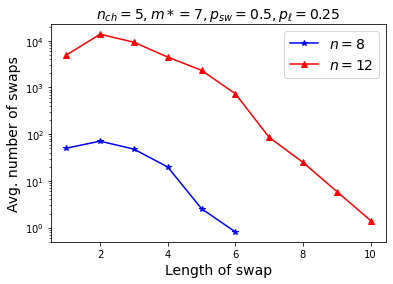

In [8]:
import matplotlib.pyplot as plt
cc_all_8node = [41.832  93.337 126.252 194.927   9.465   1.521]
cc_all_12node = [4.9430740e+03, 1.3817352e+04, 9.3195100e+03,
4.4783980e+03, 2.3305980e+03, 7.3413000e+02, 8.5468000e+01,
         2.4906000e+01, 5.9200000e+00, 1.4160000e+00]
plt.plot(range(1,7), cc_all_8node, marker='*', color='blue')
plt.plot(range(1,11), cc_all_12node, marker='^', color='red')
plt.yscale('log')
plt.legend(['$n=8$','$n=12$'], fontsize=14)
plt.ylabel('Avg. number of swaps', fontsize=14)
plt.xlabel('Length of swap', fontsize=14)
plt.title('$n_{ch}=5, m* = 7, p_{sw} = 0.5, p_\ell=0.25$', fontsize=14)
plt.savefig('swap_length_distribution.pdf')

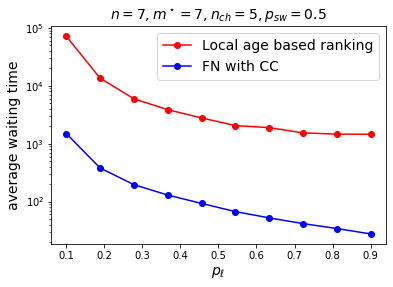

In [35]:
# mstar=8 n=7 n_ch=5 pl = 0.05,0.5,11
wt=np.array([1495.117,
 379.79900000000004,
 195.847,
 129.518,
 92.846,
 67.10999999999999,
 52.287,
 41.62399999999999,
 34.20100000000001,
 27.616000000000003])
fid=np.array([6.073,
 5.9479999999999995,
 5.736,
 5.676,
 5.546,
 5.305000000000001,
 5.104999999999999,
 4.815999999999999,
 4.49,
 3.957])
wt_local= np.array([71640.89,
 13543.265,
 5948.165,
 3864.575,
 2781.505,
 2054.54,
 1891.45,
 1534.94,
 1461.865,
 1454.57])
fid_local = np.array([7.115, 7.02, 7.0, 7.0, 7.005, 7.0, 7.0, 7.0, 7.0, 7.0])-1

import matplotlib.pyplot as plt

imp_FN = np.divide((wt_local-wt),wt)*100
imp_age_FN = np.divide((fid_local-fid),fid)*100


plt.plot(np.linspace(0.1, 0.9, 10),wt_local,color='r', marker='o')
plt.plot(np.linspace(0.1, 0.9, 10),wt,color='b', marker='o')

plt.title(r"$n = 7, m^\star = 7, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average waiting time", fontsize = 14)
plt.yscale('log')
plt.legend(["Local age based ranking","FN with CC"],fontsize = 14)
plt.savefig("FN_CCvslocal_new.pdf")

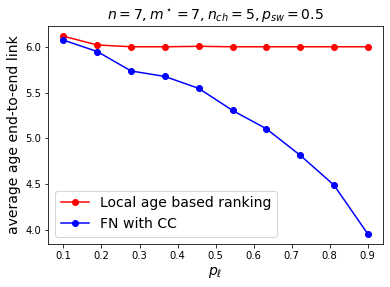

In [37]:
import matplotlib.pyplot as plt

plt.plot(np.linspace(0.1, 0.9, 10),fid_local,color='r', marker='o')
plt.plot(np.linspace(0.1, 0.9, 10),fid,color='b', marker='o')

plt.title(r"$n = 7, m^\star = 7, n_{ch} = 5, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel(r"$p_\ell$",fontsize = 14)
plt.ylabel("average age end-to-end link", fontsize = 14)
# plt.yscale('log')
plt.legend(["Local age based ranking","FN with CC"],fontsize = 14)
plt.savefig("FN_CCvslocal_age_new.pdf")

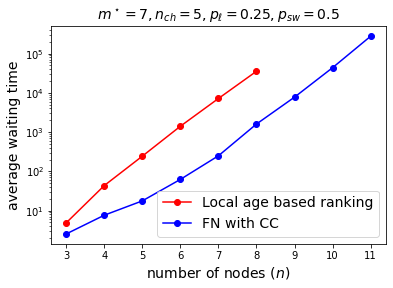

In [12]:
# mstar=8 n variable n_ch=5 pl = 0.2
wt=np.array([2.54, 7.62, 17.66, 62.27, 248.93, 1604.03, 7772.695, 43744.45, 276887.375])

wt_local= np.array([4.88, 43.44, 243.69, 1409.915, 7180.85, 35468.88])

import matplotlib.pyplot as plt


plt.plot(np.arange(3,9),wt_local,color='r', marker='o')
plt.plot(np.arange(3,12),wt,color='b', marker='o')

plt.title(r"$m^\star = 7, n_{ch} = 5, p_\ell = 0.25, p_{sw} = 0.5$", fontsize = 14)
plt.xlabel("number of nodes $(n)$",fontsize = 14)
plt.ylabel("average waiting time", fontsize = 14)
plt.yscale('log')
plt.legend(["Local age based ranking","FN with CC"],fontsize = 14)
plt.savefig("FN_CCvslocal_n_scale.pdf")

In [19]:
n = 9
m_star = 5
n_ch = 5
p_sw = 0.5

wt_all=[]
fid_all=[]
wt_std=[]
fid_std=[]

for p_l in [0.15]:#np.linspace(0.2, 0.5, 10):
    print(p_l)
    wt_wt=[]
    fid_fid=[]
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'dist') for i in range(100))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

# np.save('wt_FN_955_CC.npy',wt_all)
# np.save('fid_FN_955_CC.npy',fid_all)

n = 9
m_star = 5
n_ch = 5
p_sw = 0.5

wt_all=[]
fid_all=[]
wt_std=[]
fid_std=[]

for p_l in [0.15]:#np.linspace(0.2, 0.5, 10):
    print(p_l)
    wt_wt=[]
    fid_fid=[]
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid)(n,n_ch,m_star,p_l,p_sw,'age') for i in range(100))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

# np.save('wt_SN_955_CC.npy',wt_all)
# np.save('fid_SN_955_CC.npy',fid_all)

n = 9
m_star = 5
n_ch = 5
p_sw = 0.5

wt_all=[]
fid_all=[]
wt_std=[]
fid_std=[]

for p_l in [0.15]:
    print(p_l)
    wt_wt=[]
    fid_fid=[]
    for k in range(10):
        print(k)
        wt_list = Parallel(n_jobs=100)(delayed(wt_fid_doubling)(n,n_ch,m_star,p_l,p_sw,'age') for i in range(200))
        wt_wt.append(np.mean([wt_list[i][0] for i in range(len(wt_list))]))
        fid_fid.append(np.mean([wt_list[i][1] for i in range(len(wt_list))])-1)

    print(np.mean(wt_wt), np.std(wt_wt), np.mean(fid_fid), np.std(fid_fid))
    wt_all.append(np.mean(wt_wt))
    fid_all.append(np.mean(fid_fid))
    wt_std.append(np.std(wt_wt))
    fid_std.append(np.std(fid_fid))

# np.save('wt_DBL_965_CC.npy',wt_all)
# np.save('fid_DBL_965_CC.npy',fid_all)

0.15
0
1
2
3
4
5
6
7
8
9
49660.303 4625.848642385632 4.0 0.0
0.15
0
1
2
3
4
5
6
7
8
9
40441.009000000005 2907.107551211169 4.0 0.0
0.15
0
1
2
3
4
5
6
7
8
9
49491.81999999999 4257.617322158605 4.0 0.0


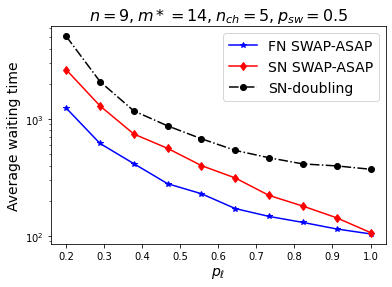

In [8]:
import matplotlib.pyplot as plt
import numpy as np

wt_DBL = np.load('wt_DBL_9515_CC.npy')
fid_DBL = np.load('fid_DBL_9515_CC.npy')
wt_FN = np.load('wt_FN_9515_CC.npy')
fid_FN = np.load('fid_FN_9515_CC.npy')
wt_SN = np.load('wt_SN_9515_CC.npy')
fid_SN = np.load('fid_SN_9515_CC.npy')



plt.plot(np.linspace(0.2,1,10), wt_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), wt_SN, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10), wt_DBL, color='black', marker='o', linestyle='dashdot')

plt.yscale('log')
plt.ylabel("Average waiting time", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['FN SWAP-ASAP', 'SN SWAP-ASAP', 'SN-doubling'], fontsize=14)
plt.title(r"$n = 9, m* = 14, n_{ch} = 5, p_{sw}=0.5$",fontsize=16)
plt.savefig('Doubling_comparison_CC_new.pdf')

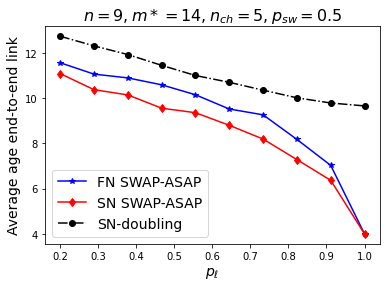

In [9]:
import matplotlib.pyplot as plt
import numpy as np

wt_DBL = np.load('wt_DBL_9515_CC.npy')
fid_DBL = np.load('fid_DBL_9515_CC.npy')
wt_FN = np.load('wt_FN_9515_CC.npy')
fid_FN = np.load('fid_FN_9515_CC.npy')
wt_SN = np.load('wt_SN_9515_CC.npy')
fid_SN = np.load('fid_SN_9515_CC.npy')



plt.plot(np.linspace(0.2,1,10), fid_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), fid_SN, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10), fid_DBL, color='black', marker='o', linestyle='dashdot')

# plt.yscale('log')
plt.ylabel("Average age end-to-end link", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['FN SWAP-ASAP', 'SN SWAP-ASAP', 'SN-doubling'], fontsize=14)
plt.title(r"$n = 9, m* = 14, n_{ch} = 5, p_{sw}=0.5$",fontsize=16)
plt.savefig('Doubling_comparison_CC_fid_new.pdf')

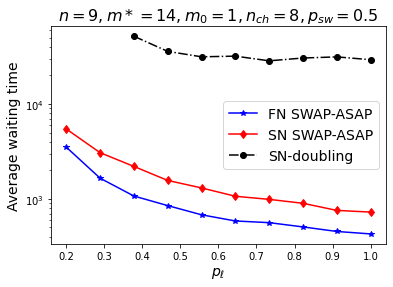

In [13]:
import matplotlib.pyplot as plt
import numpy as np

wt_DBL = np.load('wt_DBLdistill_9815m2_CC.npy')
fid_DBL = np.load('fid_DBLdistill_9815m2_CC.npy')
wt_FN = np.load('wt_FNdistill_9815m2_CC.npy')
fid_FN = np.load('fid_FNdistill_9815m2_CC.npy')
wt_SN = np.load('wt_SNdistill_9815m2_CC.npy')
fid_SN = np.load('fid_SNdistill_9815m2_CC.npy')

plt.plot(np.linspace(0.2,1,10), wt_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), wt_SN, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10)[2:], wt_DBL, color='black', marker='o', linestyle='dashdot')

plt.yscale('log')
plt.ylabel("Average waiting time", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['FN SWAP-ASAP', 'SN SWAP-ASAP', 'SN-doubling'], fontsize=14)
plt.title(r"$n = 9, m* = 14, m_0=1, n_{ch} = 8, p_{sw}=0.5$",fontsize=16)
plt.savefig('Doubling_comparison_CC_distill_new.pdf')

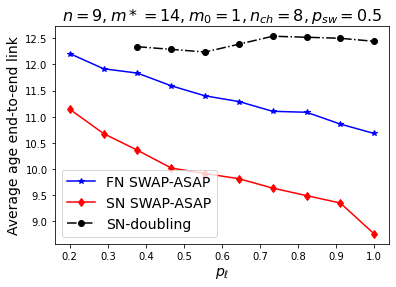

In [14]:
import matplotlib.pyplot as plt
import numpy as np

wt_DBL = np.load('wt_DBLdistill_9815m2_CC.npy')
fid_DBL = np.load('fid_DBLdistill_9815m2_CC.npy')
wt_FN = np.load('wt_FNdistill_9815m2_CC.npy')
fid_FN = np.load('fid_FNdistill_9815m2_CC.npy')
wt_SN = np.load('wt_SNdistill_9815m2_CC.npy')
fid_SN = np.load('fid_SNdistill_9815m2_CC.npy')

plt.plot(np.linspace(0.2,1,10), fid_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), fid_SN, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10)[2:], fid_DBL, color='black', marker='o', linestyle='dashdot')

# plt.yscale('log')
plt.ylabel("Average age end-to-end link", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['FN SWAP-ASAP', 'SN SWAP-ASAP', 'SN-doubling'], fontsize=14)
plt.title(r"$n = 9, m* = 14, m_0=1, n_{ch} = 8, p_{sw}=0.5$",fontsize=16)
plt.savefig('Doubling_comparison_CC_distill_fid_new.pdf')

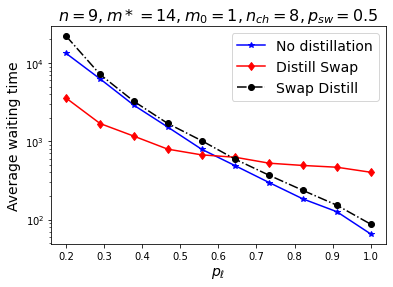

In [10]:
import matplotlib.pyplot as plt
import numpy as np

wt_FN = np.load('wt_FN_9815m2_CC.npy')
fid_FN = np.load('fid_FN_9815m2_CC.npy')
wt_FN_dlsw = np.load('wt_FN_9815m2dlsw_CC.npy')
fid_FN_dlsw = np.load('fid_FN_9815m2dlsw_CC.npy')
wt_FN_swdl = np.load('wt_FN_9815m2swdl_CC.npy')
fid_FN_swdl = np.load('fid_FN_9815m2swdl_CC.npy')

plt.plot(np.linspace(0.2,1,10), wt_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), wt_FN_dlsw, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10), wt_FN_swdl, color='black', marker='o', linestyle='dashdot')

plt.yscale('log')
plt.ylabel("Average waiting time", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['No distillation', 'Distill Swap', 'Swap Distill'], fontsize=14)
plt.title(r"$n = 9, m* = 14, m_0=1, n_{ch} = 8, p_{sw}=0.5$",fontsize=16)
plt.savefig('CC_distill_new.pdf')

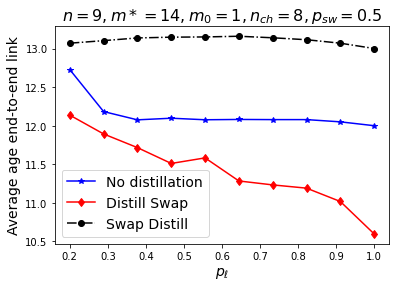

In [12]:
import matplotlib.pyplot as plt
import numpy as np

wt_FN = np.load('wt_FN_9815m2_CC.npy')
fid_FN = np.load('fid_FN_9815m2_CC.npy')
wt_FN_dlsw = np.load('wt_FN_9815m2dlsw_CC.npy')
fid_FN_dlsw = np.load('fid_FN_9815m2dlsw_CC.npy')
wt_FN_swdl = np.load('wt_FN_9815m2swdl_CC.npy')
fid_FN_swdl = np.load('fid_FN_9815m2swdl_CC.npy')

plt.plot(np.linspace(0.2,1,10), fid_FN, color='blue', marker='*')
plt.plot(np.linspace(0.2,1,10), fid_FN_dlsw, color='red', marker='d')
plt.plot(np.linspace(0.2,1,10), fid_FN_swdl, color='black', marker='o', linestyle='dashdot')

# plt.yscale('log')
plt.ylabel("Average age end-to-end link", fontsize=14)
plt.xlabel(r"$p_\ell$", fontsize=14)
plt.legend(['No distillation', 'Distill Swap', 'Swap Distill'], fontsize=14)
plt.title(r"$n = 9, m* = 14, m_0=1, n_{ch} = 8, p_{sw}=0.5$",fontsize=16)
plt.savefig('CC_distill_fid_new.pdf')